<a href="https://colab.research.google.com/github/deborahpongeluppe/Deborahpongeluppe/blob/main/TestA_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A/B Analysis: Conversion and Order Value Test

In [1]:
import pandas as pd

In [2]:
from google.colab import files
uploaded = files.upload()

Saving hypotheses_us.csv to hypotheses_us.csv


In [3]:
from google.colab import files
uploaded = files.upload()

Saving orders_us.csv to orders_us.csv


In [4]:
from google.colab import files
uploaded = files.upload()

Saving visits_us.csv to visits_us.csv


In [5]:
hypotheses_us= pd.read_csv('hypotheses_us.csv')
order_us= pd.read_csv('orders_us.csv')
visits_us= pd.read_csv('visits_us.csv')
print(hypotheses_us)
print(order_us)
print(visits_us)

           Hypothesis;Reach;Impact;Confidence;Effort
0  Add two new channels for attracting traffic. T...
1  Launch your own delivery service. This will sh...
2  Add product recommendation blocks to the store...
3  Change the category structure. This will incre...
4  Change the background color on the main page. ...
5  Add a customer review page. This will increase...
6  Show banners with current offers and sales on ...
7  Add a subscription form to all the main pages....
8  Launch a promotion that gives users discounts ...
      transactionId   visitorId        date  revenue group
0        3667963787  3312258926  2019-08-15     30.4     B
1        2804400009  3642806036  2019-08-15     15.2     B
2        2961555356  4069496402  2019-08-15     10.2     A
3        3797467345  1196621759  2019-08-15    155.1     B
4        2282983706  2322279887  2019-08-15     40.5     B
...             ...         ...         ...      ...   ...
1192     2662137336  3733762160  2019-08-14    100.8     

In [6]:
usuarios_grupo_A = set(order_us[order_us['group'] == 'A']['visitorId'])
usuarios_grupo_B = set(order_us[order_us['group'] == 'B']['visitorId'])
usuarios_duplicados = usuarios_grupo_A.intersection(usuarios_grupo_B)
print(f"Usuários que aparecem em ambos os grupos: {len(usuarios_duplicados)}")
if len(usuarios_duplicados) > 0:
    print("Alguns usuários estão nos dois grupos")
    print(f"Exemplos: {list(usuarios_duplicados)[:5]}")

Usuários que aparecem em ambos os grupos: 58
Alguns usuários estão nos dois grupos
Exemplos: [3957174400, 3984495233, 2780786433, 1294878855, 1648269707]


In [7]:
pedidos_duplicados = order_us[order_us['visitorId'].isin(usuarios_duplicados)]
print(f"Total de pedidos dos usuários duplicados: {len(pedidos_duplicados)}")
pedidos_duplicados.head()
print("Datas dos pedidos dos usuários duplicados:")
print(sorted(pedidos_duplicados['date'].unique()))
pedidos_por_data = pedidos_duplicados.groupby('date').size()
print("\nQuantidade de pedidos duplicados por data:")
print(pedidos_por_data)

Total de pedidos dos usuários duplicados: 181
Datas dos pedidos dos usuários duplicados:
['2019-08-01', '2019-08-02', '2019-08-03', '2019-08-04', '2019-08-05', '2019-08-06', '2019-08-07', '2019-08-08', '2019-08-09', '2019-08-10', '2019-08-11', '2019-08-12', '2019-08-13', '2019-08-14', '2019-08-15', '2019-08-16', '2019-08-17', '2019-08-18', '2019-08-19', '2019-08-20', '2019-08-21', '2019-08-22', '2019-08-23', '2019-08-24', '2019-08-25', '2019-08-26', '2019-08-27', '2019-08-28', '2019-08-29', '2019-08-30', '2019-08-31']

Quantidade de pedidos duplicados por data:
date
2019-08-01     5
2019-08-02     2
2019-08-03     2
2019-08-04     8
2019-08-05     5
2019-08-06     8
2019-08-07     3
2019-08-08     7
2019-08-09    11
2019-08-10     2
2019-08-11     3
2019-08-12     9
2019-08-13     1
2019-08-14    16
2019-08-15    10
2019-08-16     2
2019-08-17     5
2019-08-18     6
2019-08-19     1
2019-08-20     2
2019-08-21     5
2019-08-22    10
2019-08-23     7
2019-08-24     4
2019-08-25     4
20

In [8]:
analise_grupos = pedidos_duplicados.groupby(['date', 'group']).size().unstack(fill_value=0)
print("Pedidos dos usuários duplicados por data e grupo:")
print(analise_grupos)

Pedidos dos usuários duplicados por data e grupo:
group       A  B
date            
2019-08-01  1  4
2019-08-02  1  1
2019-08-03  0  2
2019-08-04  5  3
2019-08-05  3  2
2019-08-06  3  5
2019-08-07  2  1
2019-08-08  2  5
2019-08-09  5  6
2019-08-10  1  1
2019-08-11  2  1
2019-08-12  5  4
2019-08-13  0  1
2019-08-14  7  9
2019-08-15  5  5
2019-08-16  0  2
2019-08-17  4  1
2019-08-18  4  2
2019-08-19  1  0
2019-08-20  2  0
2019-08-21  3  2
2019-08-22  6  4
2019-08-23  5  2
2019-08-24  2  2
2019-08-25  2  2
2019-08-26  0  3
2019-08-27  5  5
2019-08-28  2  6
2019-08-29  5  5
2019-08-30  2  3
2019-08-31  4  3


In [9]:
exemplo_usuario = list(usuarios_duplicados)[0]
pedidos_exemplo = pedidos_duplicados[pedidos_duplicados['visitorId'] == exemplo_usuario]
print(f"\nExemplo do usuário {exemplo_usuario}:")
print(pedidos_exemplo[['date', 'group', 'visitorId']].sort_values('date'))


Exemplo do usuário 3957174400:
           date group   visitorId
269  2019-08-18     A  3957174400
561  2019-08-26     B  3957174400


In [10]:
total_usuarios = len(order_us['visitorId'].unique())
total_pedidos = len(order_us)

print(f"Total de usuários únicos: {total_usuarios}")
print(f"Total de pedidos: {total_pedidos}")
print(f"Usuários duplicados: {len(usuarios_duplicados)} ({len(usuarios_duplicados)/total_usuarios*100:.1f}%)")
print(f"Pedidos de usuários duplicados: {len(pedidos_duplicados)} ({len(pedidos_duplicados)/total_pedidos*100:.1f}%)")

Total de usuários únicos: 1031
Total de pedidos: 1197
Usuários duplicados: 58 (5.6%)
Pedidos de usuários duplicados: 181 (15.1%)


In [11]:
total_visitas = visits_us['visits'].sum()
total_pedidos_todos = len(order_us)
taxa_conversao_com_duplicados = (total_pedidos_todos / total_visitas) * 100
print("=== ANÁLISE COM USUÁRIOS DUPLICADOS ===")
print(f"Total de visitas: {total_visitas}")
print(f"Total de pedidos: {total_pedidos_todos}")
print(f"Taxa de conversão geral: {taxa_conversao_com_duplicados:.2f}%")

=== ANÁLISE COM USUÁRIOS DUPLICADOS ===
Total de visitas: 37652
Total de pedidos: 1197
Taxa de conversão geral: 3.18%


In [12]:
pedidos_sem_duplicados = order_us[~order_us['visitorId'].isin(usuarios_duplicados)]
total_pedidos_limpos = len(pedidos_sem_duplicados)
taxa_conversao_sem_duplicados = (total_pedidos_limpos / total_visitas) * 100
print("\n=== ANÁLISE SEM USUÁRIOS DUPLICADOS ===")
print(f"Total de visitas: {total_visitas}")
print(f"Total de pedidos (sem duplicados): {total_pedidos_limpos}")
print(f"Taxa de conversão geral: {taxa_conversao_sem_duplicados:.2f}%")


=== ANÁLISE SEM USUÁRIOS DUPLICADOS ===
Total de visitas: 37652
Total de pedidos (sem duplicados): 1016
Taxa de conversão geral: 2.70%


In [13]:
print("=== COMPARAÇÃO POR GRUPO (COM DUPLICADOS) ===")
for grupo in ['A', 'B']:
    visitas_grupo = visits_us[visits_us['group'] == grupo]['visits'].sum()
    pedidos_grupo = len(order_us[order_us['group'] == grupo])
    taxa_grupo = (pedidos_grupo / visitas_grupo) * 100
    print(f"Grupo {grupo}: {pedidos_grupo} pedidos / {visitas_grupo} visitas = {taxa_grupo:.2f}%")
print("\n=== COMPARAÇÃO POR GRUPO (SEM DUPLICADOS) ===")
for grupo in ['A', 'B']:
    visitas_grupo = visits_us[visits_us['group'] == grupo]['visits'].sum()
    pedidos_grupo = len(pedidos_sem_duplicados[pedidos_sem_duplicados['group'] == grupo])
    taxa_grupo = (pedidos_grupo / visitas_grupo) * 100
    print(f"Grupo {grupo}: {pedidos_grupo} pedidos / {visitas_grupo} visitas = {taxa_grupo:.2f}%")

=== COMPARAÇÃO POR GRUPO (COM DUPLICADOS) ===
Grupo A: 557 pedidos / 18736 visitas = 2.97%
Grupo B: 640 pedidos / 18916 visitas = 3.38%

=== COMPARAÇÃO POR GRUPO (SEM DUPLICADOS) ===
Grupo A: 468 pedidos / 18736 visitas = 2.50%
Grupo B: 548 pedidos / 18916 visitas = 2.90%


In [15]:
hypotheses_us = pd.read_csv('hypotheses_us.csv', sep=';')
print(hypotheses_us)

                                          Hypothesis  Reach  Impact  \
0  Add two new channels for attracting traffic. T...      3      10   
1  Launch your own delivery service. This will sh...      2       5   
2  Add product recommendation blocks to the store...      8       3   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   
5  Add a customer review page. This will increase...      3       2   
6  Show banners with current offers and sales on ...      5       3   
7  Add a subscription form to all the main pages....     10       7   
8  Launch a promotion that gives users discounts ...      1       9   

   Confidence  Effort  
0           8       6  
1           4      10  
2           7       3  
3           3       8  
4           1       1  
5           2       3  
6           8       3  
7           8       5  
8           9       5  


In [16]:
hypotheses_us['Ease'] = 10 - hypotheses_us['Effort']
hypotheses_us['ICE_Score'] = hypotheses_us['Impact'] * hypotheses_us['Confidence'] * hypotheses_us['Ease']
hypotheses_ice = hypotheses_us.sort_values('ICE_Score', ascending=False)
print(hypotheses_ice)

                                          Hypothesis  Reach  Impact  \
8  Launch a promotion that gives users discounts ...      1       9   
0  Add two new channels for attracting traffic. T...      3      10   
7  Add a subscription form to all the main pages....     10       7   
6  Show banners with current offers and sales on ...      5       3   
2  Add product recommendation blocks to the store...      8       3   
5  Add a customer review page. This will increase...      3       2   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   
1  Launch your own delivery service. This will sh...      2       5   

   Confidence  Effort  Ease  ICE_Score  
8           9       5     5        405  
0           8       6     4        320  
7           8       5     5        280  
6           8       3     7        168  
2           7       3     7        147  
5           2       3     7         28  
3 

Based on the ICE Score analysis, hypothesis prioritization was determined by considering impact, confidence, and ease of implementation. Hypothesis 8, regarding discount promotions, is the top priority; it combines high impact with high confidence, achieving the highest ICE score (405). Next is Hypothesis 0, which proposes two new traffic channels; although it offers maximum potential impact, its implementation is more complex, justifying its second-place ranking with an ICE score of 320. The third priority is Hypothesis 7—concerning the sign-up form—which presents a balanced combination of impact, confidence, and ease of execution, with an ICE score of 280. This prioritization allows initial efforts to focus on initiatives with the greatest potential return, while the remaining ones can be planned for subsequent stages.

In [17]:
hypotheses_us['RICE_Score'] = hypotheses_us['Reach'] * hypotheses_us['Impact'] * hypotheses_us['Confidence'] * hypotheses_us['Ease']
hypotheses_rice = hypotheses_us.sort_values('RICE_Score', ascending=False)
print(hypotheses_rice[['Hypothesis', 'Reach', 'Impact', 'Confidence', 'Ease', 'ICE_Score', 'RICE_Score']])

                                          Hypothesis  Reach  Impact  \
7  Add a subscription form to all the main pages....     10       7   
2  Add product recommendation blocks to the store...      8       3   
0  Add two new channels for attracting traffic. T...      3      10   
6  Show banners with current offers and sales on ...      5       3   
8  Launch a promotion that gives users discounts ...      1       9   
3  Change the category structure. This will incre...      8       3   
5  Add a customer review page. This will increase...      3       2   
4  Change the background color on the main page. ...      3       1   
1  Launch your own delivery service. This will sh...      2       5   

   Confidence  Ease  ICE_Score  RICE_Score  
7           8     5        280        2800  
2           7     7        147        1176  
0           8     4        320         960  
6           8     7        168         840  
8           9     5        405         405  
3           3     2

Two prioritization frameworks were used: ICE and RICE.
The ICE framework uses the formula Impact × Confidence × Ease, focusing on balancing impact, confidence, and ease of implementation. In contrast, the RICE framework uses the formula (Reach × Impact × Confidence) ÷ Ease, adding the Reach factor and treating Ease as a divisor, which significantly alters the prioritization logic.
The main difference observed between the two methods lies in the influence of the Reach factor; it becomes decisive in RICE because it represents the number of people impacted by each initiative.
Certain changes in prioritization were particularly significant.
The sign-up form (Hypothesis 7) moved from 3rd place in ICE (280 points) to 1st place in RICE (2,800 points). This occurred because the high Reach score (10) multiplies the initiative's total impact, favoring improvements that affect a large portion of the user base.
Recommendation blocks (Hypothesis 2) ranked 4th in ICE (147 points) but rose to 2nd place in RICE (1,176 points). In this instance, the high Reach (8) offset the lower ease of implementation, highlighting the value of initiatives with broad, ongoing reach.
Conversely, the discount promotion (Hypothesis 8) showed the opposite trend. Despite topping the ICE ranking with 405 points, it fell to 5th place in RICE—though it still held 405 points. This happens because the very low Reach (1) limits the total impact, characterizing the action as a one-off event with limited scalability.
These shifts occur because the Reach factor directly multiplies the impact, better reflecting business realities. A hypothesis that reaches ten times as many people holds proportionally greater impact potential, particularly regarding revenue and growth. Thus, RICE prioritizes more scalable initiatives, whereas ICE favors strong ideas even when their reach is initially limited.

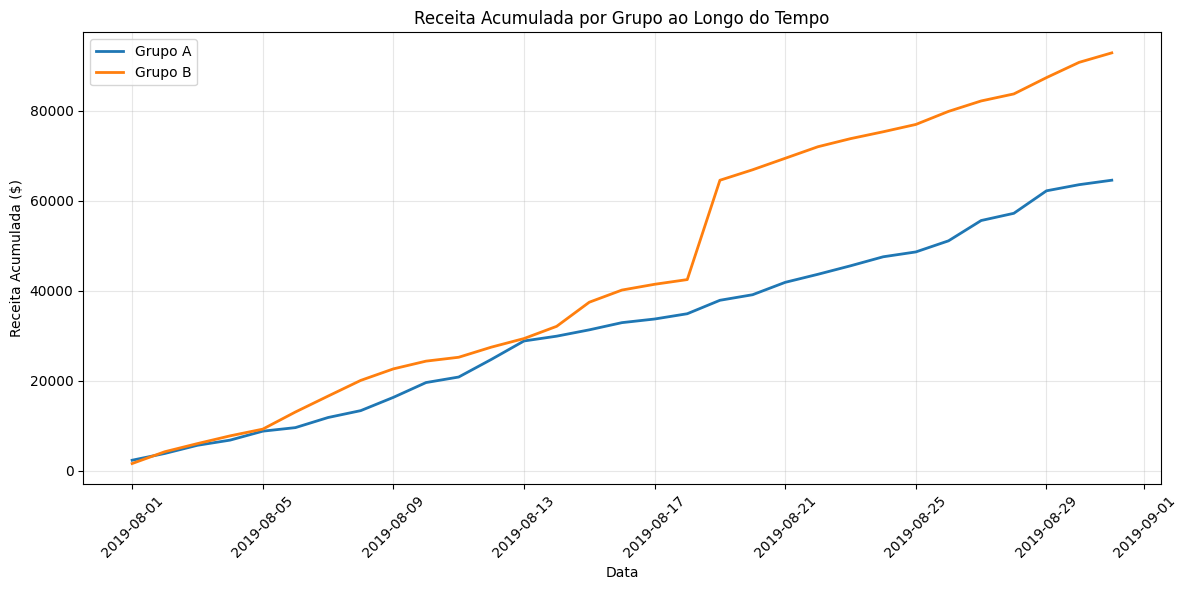

In [18]:
import matplotlib.pyplot as plt
import numpy as np
order_us['date'] = pd.to_datetime(order_us['date'])
receita_diaria = order_us.groupby(['date', 'group'])['revenue'].sum().reset_index()
receita_acumulada = receita_diaria.groupby('group')['revenue'].cumsum().reset_index()
receita_diaria['receita_acumulada'] = receita_acumulada['revenue']
plt.figure(figsize=(12, 6))
for grupo in ['A', 'B']:
    dados_grupo = receita_diaria[receita_diaria['group'] == grupo]
    plt.plot(dados_grupo['date'], dados_grupo['receita_acumulada'],
             label=f'Grupo {grupo}', linewidth=2)
plt.title('Receita Acumulada por Grupo ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Receita Acumulada ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

When it is stated that Group B shows better performance, this conclusion can be interpreted in different ways, which must be clearly distinguished.
One possibility is that Group B generated higher total revenue over the test period. In this case, the sum of Group B's accumulated revenue exceeds that of Group A, and its accumulated revenue curve remains consistently above Group A's curve throughout the experiment. This reading indicates superior overall performance within the analyzed timeframe.
Another possible interpretation is that Group B exhibits faster growth. Here, the focus is not merely on the final accumulated value but on the rate of revenue generation. A steeper slope in Group B's curve suggests that users in this group convert or generate revenue more quickly, even if the final total has yet to be evaluated.
Beyond these interpretations, certain critical issues must be investigated to ensure the analysis's reliability. A sensitive point concerns the presence of duplicate users across the groups. It is necessary to assess whether these users are purchasing more because they were exposed to both treatments—a factor that could artificially inflate results and compromise the independence of the groups.
Finally, it is essential to validate the statistical robustness of the test. One must verify whether the observed difference between the groups is statistically significant and whether the groups were comparable at the start of the experiment, sharing similar characteristics regarding profile, behavior, and sample size. Without these assurances, any conclusion regarding Group B's superiority remains inconclusive.

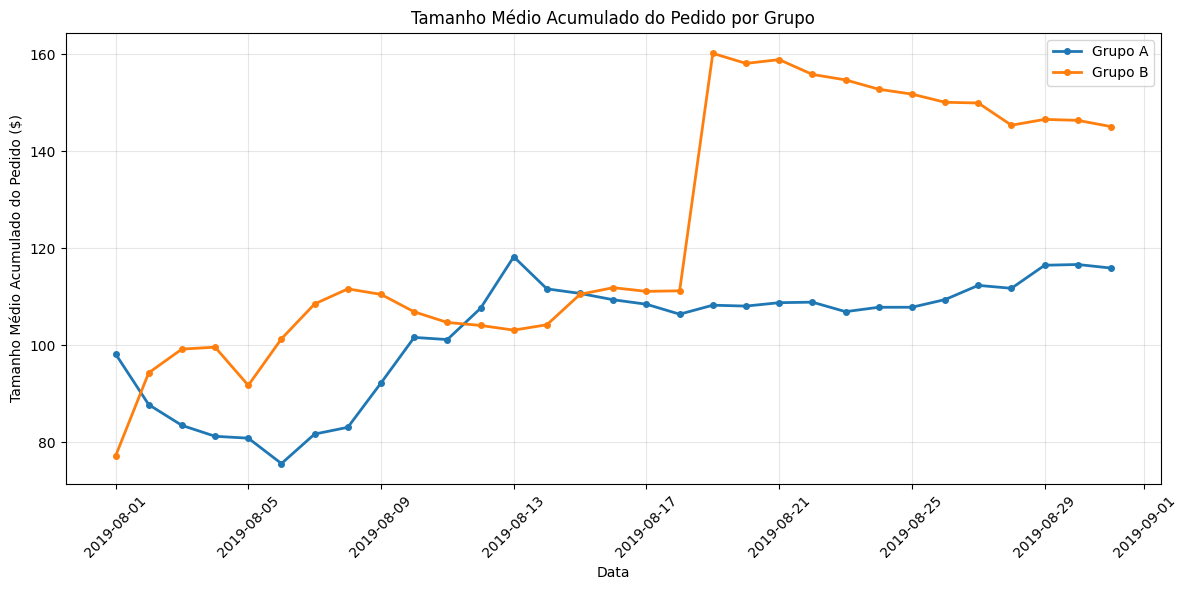

Últimos valores do tamanho médio acumulado:
Grupo A: $115.90
Grupo B: $145.06


In [19]:
order_us['date'] = pd.to_datetime(order_us['date'])
dados_diarios = order_us.groupby(['date', 'group']).agg({
    'revenue': 'sum',
    'transactionId': 'count'
}).reset_index()
dados_diarios.columns = ['date', 'group', 'receita_diaria', 'pedidos_diarios']
resultado_final = []
for grupo in ['A', 'B']:
    dados_grupo = dados_diarios[dados_diarios['group'] == grupo].copy()
    dados_grupo = dados_grupo.sort_values('date')
    dados_grupo['receita_acumulada'] = dados_grupo['receita_diaria'].cumsum()
    dados_grupo['pedidos_acumulados'] = dados_grupo['pedidos_diarios'].cumsum()
    dados_grupo['tamanho_medio_acumulado'] = dados_grupo['receita_acumulada'] / dados_grupo['pedidos_acumulados']
    resultado_final.append(dados_grupo)
dados_completos = pd.concat(resultado_final, ignore_index=True)
plt.figure(figsize=(12, 6))
for grupo in ['A', 'B']:
    dados_grupo = dados_completos[dados_completos['group'] == grupo]
    plt.plot(dados_grupo['date'], dados_grupo['tamanho_medio_acumulado'],
             label=f'Grupo {grupo}', linewidth=2, marker='o', markersize=4)
plt.title('Tamanho Médio Acumulado do Pedido por Grupo')
plt.xlabel('Data')
plt.ylabel('Tamanho Médio Acumulado do Pedido ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Últimos valores do tamanho médio acumulado:")
for grupo in ['A', 'B']:
    dados_grupo = dados_completos[dados_completos['group'] == grupo]
    ultimo_valor = dados_grupo['tamanho_medio_acumulado'].iloc[-1]
    print(f"Grupo {grupo}: ${ultimo_valor:.2f}")

In [20]:
diferenca_absoluta = 145.06 - 115.90
diferenca_percentual = (145.06 - 115.90) / 115.90 * 100
print(f"Grupo B tem pedidos ${diferenca_absoluta:.2f} maiores")
print(f"Isso representa {diferenca_percentual:.1f}% a mais por pedido")

Grupo B tem pedidos $29.16 maiores
Isso representa 25.2% a mais por pedido


There is a significant difference in average order value between the groups. In Group A, the average order value is $115.90, based on all orders placed since the test began. In contrast, Group B shows an average order value of $145.06—meaning orders are approximately 25% more valuable than those in Group A.
This difference may indicate a shift in the purchasing behavior of users exposed to the Group B treatment. The tested variation might be encouraging higher-value purchases, whether by prompting users to add more items to their carts or by increasing the average price per item. A psychological effect cannot be ruled out either, where the treatment leads users to perceive greater value in the offer and, consequently, spend more.
Another plausible hypothesis involves the selection of users with different profiles. Group B might be attracting consumers with higher purchasing power or filtering out users less willing to spend; this would naturally raise the average order value without necessarily altering individual purchasing behavior.
To deepen the analysis, certain hypotheses need to be investigated. From a product or service perspective, it is important to determine whether the tested change promotes higher-value items or involves explicit or implicit incentives for larger purchases—such as free shipping above a certain threshold or tiered discounts.
From a behavioral standpoint, it is essential to analyze whether Group B users are placing fewer, higher-value orders or maintaining the same purchase frequency but with higher average order values. This distinction is crucial for understanding whether the observed impact stems from the monetization strategy or from a shift in the profile of the users who convert.

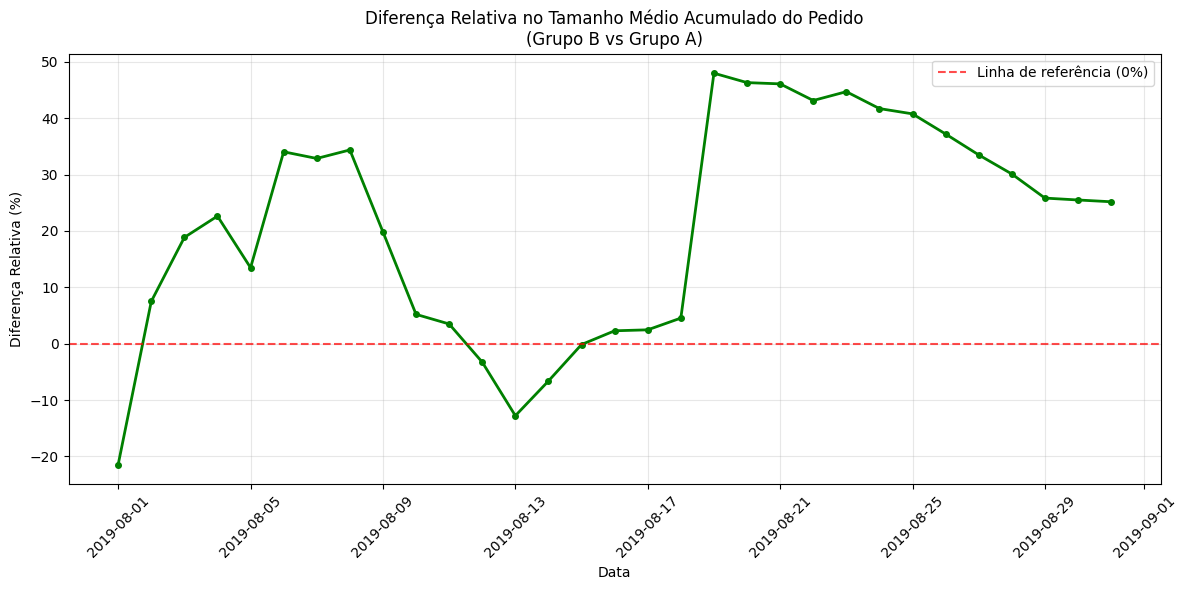

Evolução da diferença relativa:
Valor inicial: -21.4%
Valor final: 25.2%
Valor máximo: 48.0%
Valor mínimo: -21.4%


In [21]:
dados_pivot = dados_completos.pivot(index='date', columns='group', values='tamanho_medio_acumulado')
dados_pivot['diferenca_relativa'] = ((dados_pivot['B'] - dados_pivot['A']) / dados_pivot['A']) * 100
plt.figure(figsize=(12, 6))
plt.plot(dados_pivot.index, dados_pivot['diferenca_relativa'],
         linewidth=2, marker='o', markersize=4, color='green')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Linha de referência (0%)')
plt.title('Diferença Relativa no Tamanho Médio Acumulado do Pedido\n(Grupo B vs Grupo A)')
plt.xlabel('Data')
plt.ylabel('Diferença Relativa (%)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
print("Evolução da diferença relativa:")
print(f"Valor inicial: {dados_pivot['diferenca_relativa'].iloc[0]:.1f}%")
print(f"Valor final: {dados_pivot['diferenca_relativa'].iloc[-1]:.1f}%")
print(f"Valor máximo: {dados_pivot['diferenca_relativa'].max():.1f}%")
print(f"Valor mínimo: {dados_pivot['diferenca_relativa'].min():.1f}%")

The evolution of the relative difference in order value between the groups reveals a significant shift over time. At the start of the test, Group B underperformed compared to Group A, with order values ​​21.4% lower. This initial result suggests that the new treatment may have caused confusion or friction during early interactions, discouraging some users. It is also possible that there was an adjustment period during which the first users exposed to the change reacted negatively.
Over the analyzed period, this scenario changed dramatically. By the end, Group B was recording order values ​​25.2% higher than those of Group A, completely reversing the performance observed at the start. This variation represents a shift of approximately 47 percentage points—moving from -21.4% to +25.2%—marking a substantial evolution in user behavior.
At one point during the test, the difference peaked at 48.0% in favor of Group B, indicating a period of exceptional performance for the treatment. Conversely, the minimum value of -21.4% observed at the beginning confirms that the poorest performance occurred during the initial interactions with the new experience.
These results allow for several relevant conclusions and conjectures. The first is the existence of a possible learning or adaptation effect. The curve suggests that users needed time to understand and get used to the change; after this initial period, the response to the treatment became clearly positive.
A second hypothesis involves a temporal selection effect. Over time, users who did not adapt or failed to see value in the change may have reduced their usage or abandoned the service, while those for whom the treatment was most beneficial remained, thereby raising the average order value.
Finally, there are indications of a treatment maturation effect. The impact of the change may not be immediate but rather cumulative, becoming more effective as users repeatedly interact with the new flow or feature. This progressive effect helps explain the consistent improvement in Group B's performance over time.

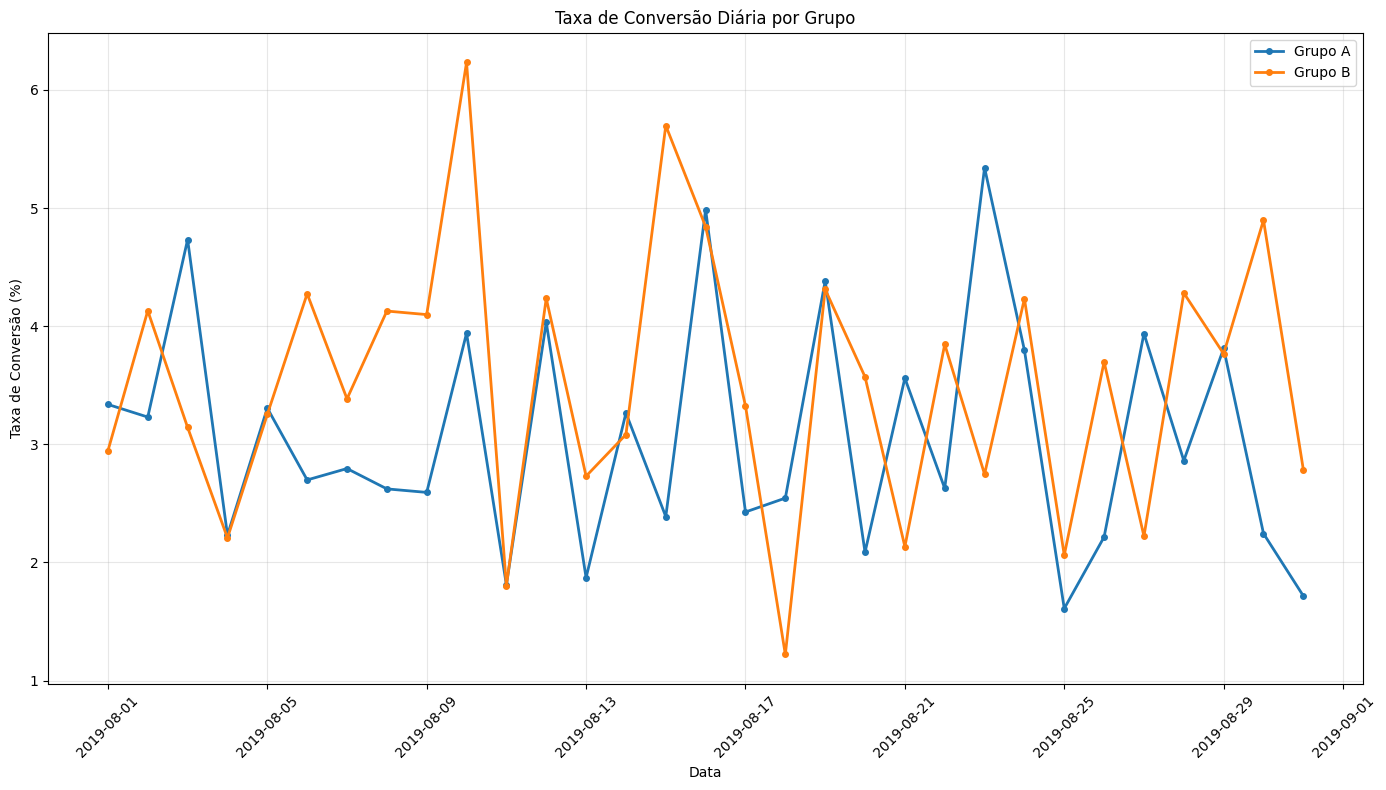

=== ESTATÍSTICAS DA TAXA DE CONVERSÃO DIÁRIA ===

Grupo A:
Taxa média: 3.07%
Taxa mediana: 2.80%
Desvio padrão: 0.99%
Taxa mínima: 1.61%
Taxa máxima: 5.34%

Grupo B:
Taxa média: 3.53%
Taxa mediana: 3.57%
Desvio padrão: 1.13%
Taxa mínima: 1.22%
Taxa máxima: 6.23%


In [22]:
visits_us['date'] = pd.to_datetime(visits_us['date'])
pedidos_diarios = order_us.groupby(['date', 'group']).size().reset_index(name='pedidos')
conversao_diaria = visits_us.merge(pedidos_diarios, on=['date', 'group'], how='left')
conversao_diaria['pedidos'] = conversao_diaria['pedidos'].fillna(0)
conversao_diaria['taxa_conversao'] = (conversao_diaria['pedidos'] / conversao_diaria['visits']) * 100
plt.figure(figsize=(14, 8))
for grupo in ['A', 'B']:
    dados_grupo = conversao_diaria[conversao_diaria['group'] == grupo]
    plt.plot(dados_grupo['date'], dados_grupo['taxa_conversao'],
             label=f'Grupo {grupo}', linewidth=2, marker='o', markersize=4)
plt.title('Taxa de Conversão Diária por Grupo')
plt.xlabel('Data')
plt.ylabel('Taxa de Conversão (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("=== ESTATÍSTICAS DA TAXA DE CONVERSÃO DIÁRIA ===")
for grupo in ['A', 'B']:
    dados_grupo = conversao_diaria[conversao_diaria['group'] == grupo]
    print(f"\nGrupo {grupo}:")
    print(f"Taxa média: {dados_grupo['taxa_conversao'].mean():.2f}%")
    print(f"Taxa mediana: {dados_grupo['taxa_conversao'].median():.2f}%")
    print(f"Desvio padrão: {dados_grupo['taxa_conversao'].std():.2f}%")
    print(f"Taxa mínima: {dados_grupo['taxa_conversao'].min():.2f}%")
    print(f"Taxa máxima: {dados_grupo['taxa_conversao'].max():.2f}%")

When analyzing conversion rate and average order value together, it is evident that Group B significantly outperforms Group A. While Group A has an average conversion rate of 3.07% and an average order value of US$115.90, Group B achieves a conversion rate of 3.53% and an average order value of US$145.06. This represents a simultaneous gain in two key revenue drivers: a higher number of converting users and greater value captured per conversion. Since revenue is directly influenced by the product of traffic, conversion rate, and average order value, Group B tends to generate substantially more total revenue, even if traffic volume remains equivalent between the groups.
The fact that Group B exhibits both a higher conversion rate and a higher average order value is particularly significant, as it defies a common trade-off seen in many scenarios where an increase in average order value often accompanies a drop in conversion, or vice versa. In this case, the results suggest that Group B offers a clearer and more attractive value proposition, with less friction in the purchasing process and a higher perceived value among users. This indicates not only a greater propensity to purchase but also greater confidence in spending more.
Regarding the consistency of the results, Group A shows a lower standard deviation (0.99%); however, its mean is higher than its median, indicating a right-skewed distribution where a few very strong results pull up the average while most values ​​remain at lower levels. Conversely, although Group B has a slightly higher standard deviation (1.13%), its mean and median are virtually identical, characterizing a more symmetrical distribution and more predictable performance over time. Thus, even with greater absolute variability, Group B operates at a higher performance level and demonstrates greater reliability as a basis for results. Taken together, the data indicate that Group B not only outperforms Group A on average but also exhibits a healthier combination of conversion, monetization, and result distribution. Barring any associated additional costs or structural risks, Group B can be viewed not merely as the winner of the comparison, but as a structural improvement in business performance.

/tmp/ipykernel_1110/1734936834.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conversao_cumulativa = conversao_diaria_sorted.groupby('group').apply(


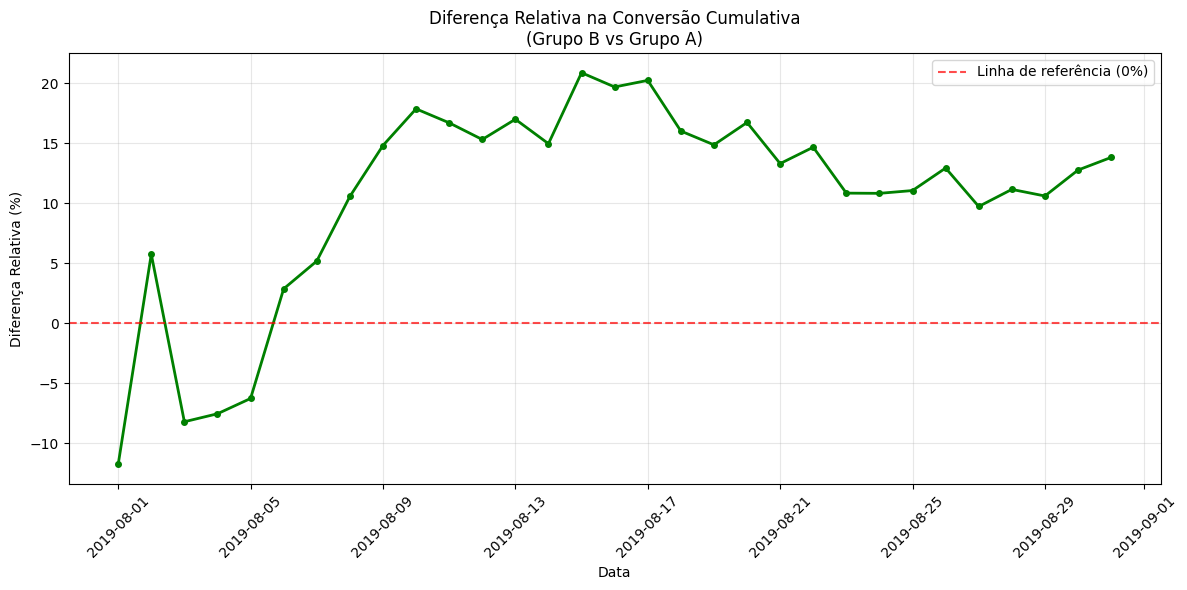

Evolução da diferença relativa na conversão:
Valor inicial: -11.8%
Valor final: 13.8%
Valor máximo: 20.9%
Valor mínimo: -11.8%


In [23]:
conversao_diaria_sorted = conversao_diaria.sort_values('date')
conversao_cumulativa = conversao_diaria_sorted.groupby('group').apply(
    lambda x: x.assign(
        pedidos_cum = x['pedidos'].cumsum(),
        visits_cum = x['visits'].cumsum(),
        conversao_cum = (x['pedidos'].cumsum() / x['visits'].cumsum()) * 100
    )
).reset_index(drop=True)
grupo_a = conversao_cumulativa[conversao_cumulativa['group'] == 'A']
grupo_b = conversao_cumulativa[conversao_cumulativa['group'] == 'B']
diferenca_relativa = ((grupo_b['conversao_cum'].values - grupo_a['conversao_cum'].values) / grupo_a['conversao_cum'].values) * 100
plt.figure(figsize=(12, 6))
plt.plot(grupo_a['date'], diferenca_relativa,
         linewidth=2, marker='o', markersize=4, color='green')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Linha de referência (0%)')
plt.title('Diferença Relativa na Conversão Cumulativa\n(Grupo B vs Grupo A)')
plt.xlabel('Data')
plt.ylabel('Diferença Relativa (%)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
print("Evolução da diferença relativa na conversão:")
print(f"Valor inicial: {diferenca_relativa[0]:.1f}%")
print(f"Valor final: {diferenca_relativa[-1]:.1f}%")
print(f"Valor máximo: {diferenca_relativa.max():.1f}%")
print(f"Valor mínimo: {diferenca_relativa.min():.1f}%")

The relative difference in conversion rate allows for a direct comparison of Group B’s performance against Group A over time, answering the central question: is Group B converting better or worse than Group A, and by what margin? This metric reveals not only which group performs better but also how that relationship evolves throughout the analyzed period.
At the start of the test, Group B underperformed compared to Group A, showing a relative difference of -11.8%. This indicates that, at that time, Group B was converting approximately 11.8% less than Group A. In practical terms, if Group A had a conversion rate of 10%, Group B would be converting at around 8.8%. This figure represents the lowest performance observed for Group B across the entire period.
Over time, however, a progressive improvement in Group B’s performance is evident, culminating in a complete reversal of the initial scenario. By the end of the analyzed period, the relative difference reached 13.8%, indicating that Group B was converting 13.8% better than Group A. This result highlights a structural shift in performance between the groups.
Furthermore, at one point during the test, Group B reached a performance peak with a maximum relative difference of 20.9%, meaning it was converting 20.9% more than Group A. This point represents Group B’s best relative performance throughout the experiment.
In summary, the analysis of the relative conversion difference reveals a clear trajectory of evolution for Group B: starting with underperformance at the beginning of the test, moving through a consistent recovery, and ultimately surpassing Group A in a significant and sustained manner by the end of the analyzed period.

In [24]:
pedidos_por_usuario = order_us.groupby('visitorId').size()
percentil_95 = pedidos_por_usuario.quantile(0.95)
percentil_99 = pedidos_por_usuario.quantile(0.99)
print(f"Percentil 95: {percentil_95}")
print(f"Percentil 99: {percentil_99}")

Percentil 95: 2.0
Percentil 99: 4.0


The 95th percentile means that 95% of users placed 2 orders or fewer, while the 99th percentile means that 99% of users placed 4 orders or fewer; this shows us that users place few orders.

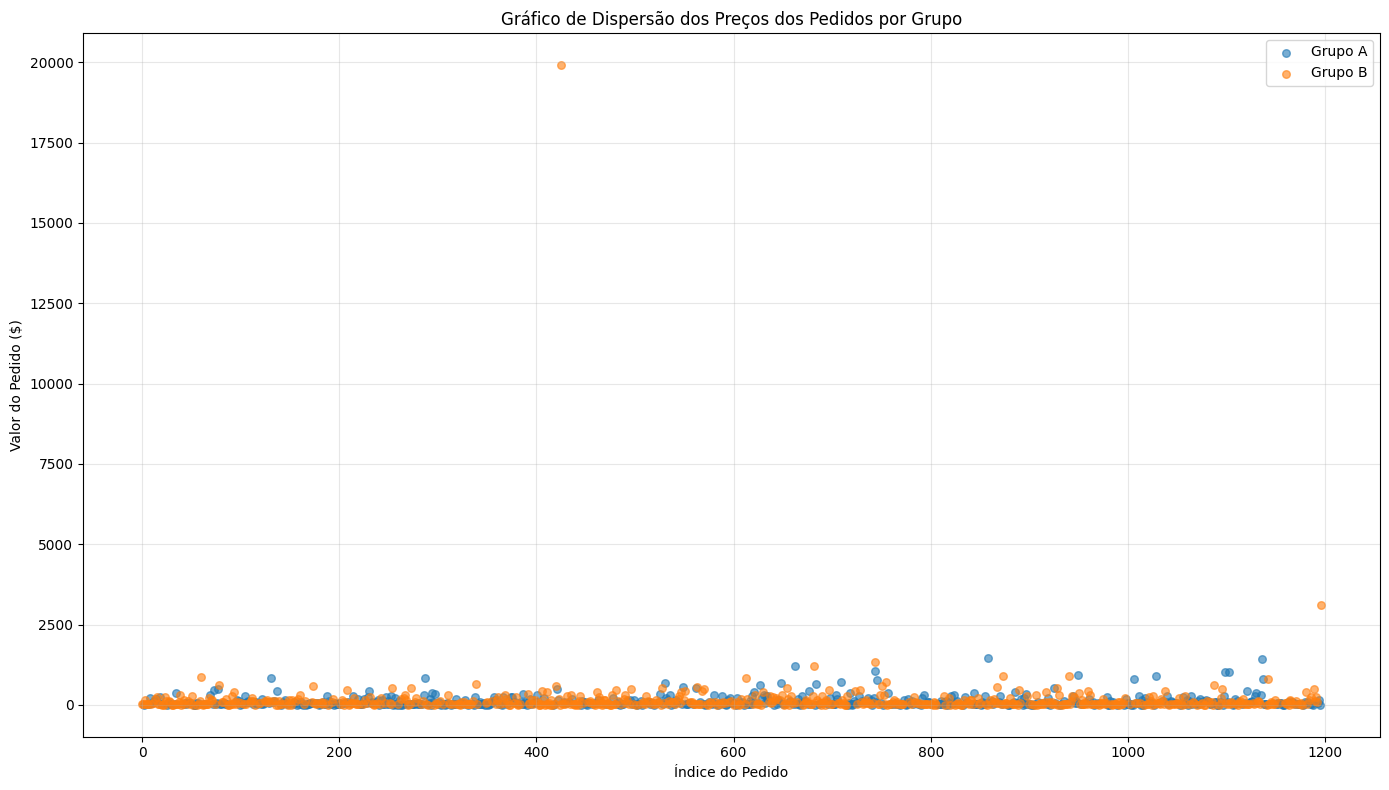

=== ESTATÍSTICAS DOS PREÇOS ===

Grupo A:
Valor médio: $115.90
Valor mediano: $50.10
Valor mínimo: $5.00
Valor máximo: $1450.20
Desvio padrão: $182.36

Grupo B:
Valor médio: $145.06
Valor mediano: $50.35
Valor mínimo: $5.10
Valor máximo: $19920.40
Desvio padrão: $806.99


In [25]:
plt.figure(figsize=(14, 8))
for grupo in ['A', 'B']:
    dados_grupo = order_us[order_us['group'] == grupo]
    plt.scatter(dados_grupo.index, dados_grupo['revenue'],
                alpha=0.6, label=f'Grupo {grupo}', s=30)
plt.title('Gráfico de Dispersão dos Preços dos Pedidos por Grupo')
plt.xlabel('Índice do Pedido')
plt.ylabel('Valor do Pedido ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("=== ESTATÍSTICAS DOS PREÇOS ===")
for grupo in ['A', 'B']:
    dados_grupo = order_us[order_us['group'] == grupo]['revenue']
    print(f"\nGrupo {grupo}:")
    print(f"Valor médio: ${dados_grupo.mean():.2f}")
    print(f"Valor mediano: ${dados_grupo.median():.2f}")
    print(f"Valor mínimo: ${dados_grupo.min():.2f}")
    print(f"Valor máximo: ${dados_grupo.max():.2f}")
    print(f"Desvio padrão: ${dados_grupo.std():.2f}")

Comparing the mean and median order values ​​reveals a clear pattern of skewness in the distributions of both groups. In Group A, the mean of US$115.90 is significantly higher than the median of US$50.10. Similarly, in Group B, the mean of US$145.06 is also well above the median of US$50.35. This discrepancy indicates that the majority of orders are concentrated at relatively low values—close to the median—while a small number of high-value orders substantially drive up the mean.
The presence of extreme outliers reinforces this interpretation. In Group A, the largest observed order was US$1,450.20—a high figure, yet plausible within a standard commercial range. In contrast, the maximum value in Group B reaches US$19,920.40, approximately 13 times higher than the maximum in Group A. This exceptional order has the potential to significantly skew mean-based metrics, making direct comparisons between the groups more sensitive to rare events.
This difference is also reflected in the data's variability. The standard deviation for Group A is US$182.36, whereas for Group B it reaches US$806.99—roughly four times higher. This indicates that order values ​​in Group B are far more dispersed, featuring a long right tail dominated by a few extremely high-value orders.
Taken together, these results suggest that both groups exhibit strongly skewed distributions, where typical user behavior is better represented by the median than by the mean. Since the medians for both groups are virtually identical—hovering around US$50—this indicates that the purchase value for the majority of users is very similar across Group A and Group B.
Thus, Group B's apparent superiority in terms of average order value appears to be driven primarily by a few extremely high-value outliers. This raises important questions regarding the nature of these extreme requests, such as their plausibility within the business model and their frequency. Before drawing definitive conclusions about which group performs better, it is advisable to investigate these outliers further and consider complementary analyses—such as robust metrics (median, percentiles) or the application of filters—to assess whether Group B's advantage holds up even after controlling for these extreme values.

In [26]:
print("=== PERCENTIS DOS PREÇOS DOS PEDIDOS ===")
for grupo in ['A', 'B']:
    dados_grupo = order_us[order_us['group'] == grupo]['revenue']
    print(f"\nGrupo {grupo}:")
    print(f"Percentil 95: ${dados_grupo.quantile(0.95):.2f}")
    print(f"Percentil 99: ${dados_grupo.quantile(0.99):.2f}")
    print(f"Percentil 99.5: ${dados_grupo.quantile(0.995):.2f}")
    print(f"Percentil 99.9: ${dados_grupo.quantile(0.999):.2f}")
print(f"\n=== PERCENTIS GERAIS ===")
print(f"Percentil 95: ${order_us['revenue'].quantile(0.95):.2f}")
print(f"Percentil 99: ${order_us['revenue'].quantile(0.99):.2f}")
print(f"Percentil 99.5: ${order_us['revenue'].quantile(0.995):.2f}")
print(f"Percentil 99.9: ${order_us['revenue'].quantile(0.999):.2f}")

=== PERCENTIS DOS PREÇOS DOS PEDIDOS ===

Grupo A:
Percentil 95: $413.48
Percentil 99: $967.80
Percentil 99.5: $1087.44
Percentil 99.9: $1436.63

Grupo B:
Percentil 95: $445.82
Percentil 99: $857.87
Percentil 99.5: $1158.89
Percentil 99.9: $9185.01

=== PERCENTIS GERAIS ===
Percentil 95: $435.54
Percentil 99: $900.90
Percentil 99.5: $1220.20
Percentil 99.9: $2792.80


In [27]:
limite_percentil_95 = order_us['revenue'].quantile(0.95)
limite_percentil_99 = order_us['revenue'].quantile(0.99)
print(f"Anomalias moderadas (acima do percentil 95): ${limite_percentil_95:.2f}")
print(f"Anomalias extremas (acima do percentil 99): ${limite_percentil_99:.2f}")
anomalias_moderadas = order_us[order_us['revenue'] > limite_percentil_95]
anomalias_extremas = order_us[order_us['revenue'] > limite_percentil_99]
print(f"\nPedidos com anomalias moderadas: {len(anomalias_moderadas)}")
print(f"Pedidos com anomalias extremas: {len(anomalias_extremas)}")

Anomalias moderadas (acima do percentil 95): $435.54
Anomalias extremas (acima do percentil 99): $900.90

Pedidos com anomalias moderadas: 60
Pedidos com anomalias extremas: 12


In [28]:
from statsmodels.stats.proportion import proportions_ztest
def calcular_conversao_por_grupo(grupo):
    visitas = visits_us[visits_us['group'] == grupo]['visits'].sum()
    pedidos = len(order_us[order_us['group'] == grupo])
    taxa = pedidos / visitas
    return visitas, pedidos, taxa
visitas_A, pedidos_A, taxa_A = calcular_conversao_por_grupo('A')
visitas_B, pedidos_B, taxa_B = calcular_conversao_por_grupo('B')
print("=== DADOS DE CONVERSÃO ===")
print(f"Grupo A: {pedidos_A} pedidos / {visitas_A} visitas = {taxa_A:.4f} ({taxa_A*100:.2f}%)")
print(f"Grupo B: {pedidos_B} pedidos / {visitas_B} visitas = {taxa_B:.4f} ({taxa_B*100:.2f}%)")
z_stat, p_value = proportions_ztest([pedidos_A, pedidos_B],
                                   [visitas_A, visitas_B])
print(f"\n=== TESTE DE SIGNIFICÂNCIA ESTATÍSTICA ===")
print(f"Estatística Z: {z_stat:.4f}")
print(f"Valor p: {p_value:.6f}")
print(f"Nível de significância (α): 0.05")
if p_value < 0.05:
    print("✅ RESULTADO: A diferença é estatisticamente significativa")
    print("   Rejeitamos H₀ - há diferença real entre os grupos")
else:
    print("❌ RESULTADO: A diferença NÃO é estatisticamente significativa")
    print("   Não rejeitamos H₀ - não há evidência de diferença real")


=== DADOS DE CONVERSÃO ===
Grupo A: 557 pedidos / 18736 visitas = 0.0297 (2.97%)
Grupo B: 640 pedidos / 18916 visitas = 0.0338 (3.38%)

=== TESTE DE SIGNIFICÂNCIA ESTATÍSTICA ===
Estatística Z: -2.2700
Valor p: 0.023207
Nível de significância (α): 0.05
✅ RESULTADO: A diferença é estatisticamente significativa
   Rejeitamos H₀ - há diferença real entre os grupos


Analysis of the conversion data indicates that Group B outperformed Group A. Group A recorded a conversion rate of 2.97%, with 557 orders from 18,736 visits, whereas Group B achieved a conversion rate of 3.38%, totaling 640 orders from 18,916 visits. This represents an absolute difference of 0.41 percentage points in favor of Group B.
To assess whether this difference could be attributed to chance, a statistical significance test was conducted. The test yielded a p-value of 0.023207—below the conventional significance level of 0.05—and a Z-statistic of -2.27; the negative sign indicates that Group B's conversion rate is higher than that of Group A.
These results allow for the rejection of the null hypothesis of equality between the groups' conversion rates. Therefore, it is concluded that the observed difference is statistically significant, indicating that Group B indeed exhibits a higher conversion rate than Group A, and that this performance is not the result of random variation but rather a genuine difference between the versions analyzed.

In [29]:
from scipy import stats
def calcular_tamanho_medio_por_grupo(grupo):
    pedidos_grupo = order_us[order_us['group'] == grupo]['revenue']
    quantidade = len(pedidos_grupo)
    media = pedidos_grupo.mean()
    return quantidade, media, pedidos_grupo
quantidade_A, media_A, valores_A = calcular_tamanho_medio_por_grupo('A')
quantidade_B, media_B, valores_B = calcular_tamanho_medio_por_grupo('B')
print("=== DADOS DO TAMANHO MÉDIO DO PEDIDO ===")
print(f"Grupo A: {quantidade_A} pedidos, média = ${media_A:.2f}")
print(f"Grupo B: {quantidade_B} pedidos, média = ${media_B:.2f}")
print(f"Diferença absoluta: ${media_B - media_A:.2f}")
print(f"Diferença relativa: {((media_B - media_A) / media_A) * 100:.1f}%")
t_stat, p_value = stats.ttest_ind(valores_A, valores_B)
print(f"\n=== TESTE DE SIGNIFICÂNCIA ESTATÍSTICA ===")
print(f"Estatística t: {t_stat:.4f}")
print(f"Valor p: {p_value:.6f}")
print(f"Nível de significância (α): 0.05")
if p_value < 0.05:
    print("✅ RESULTADO: A diferença é estatisticamente significativa")
    print("   Rejeitamos H₀ - há diferença real entre os grupos")
    if media_B > media_A:
        print(f"   O Grupo B tem pedidos significativamente maiores que o Grupo A")
    else:
        print(f"   O Grupo A tem pedidos significativamente maiores que o Grupo B")
else:
    print("❌ RESULTADO: A diferença NÃO é estatisticamente significativa")
    print("   Não rejeitamos H₀ - não há evidência de diferença real")


=== DADOS DO TAMANHO MÉDIO DO PEDIDO ===
Grupo A: 557 pedidos, média = $115.90
Grupo B: 640 pedidos, média = $145.06
Diferença absoluta: $29.17
Diferença relativa: 25.2%

=== TESTE DE SIGNIFICÂNCIA ESTATÍSTICA ===
Estatística t: -0.8346
Valor p: 0.404118
Nível de significância (α): 0.05
❌ RESULTADO: A diferença NÃO é estatisticamente significativa
   Não rejeitamos H₀ - não há evidência de diferença real


Comparing the average order value across the groups reveals a seemingly significant difference. Group A showed an average value of US$ 115.90 across 557 orders, while Group B recorded an average of US$ 145.06 across 640 orders. This represents an absolute difference of US$ 29.17, equivalent to a 25.2% increase for Group B. At first glance, this result would suggest a clear advantage for Group B in terms of monetization.
However, when applying a statistical test to assess the significance of this difference, the resulting p-value was 0.404—well above the 0.05 significance level. This indicates that the observed difference between the average values ​​is not statistically significant; in other words, we cannot confidently state that Group B actually has a higher average order value than Group A within the population as a whole.
This apparent paradox—a high percentage difference lacking statistical significance—can be explained primarily by the high variability of order values. As previously noted, the price data exhibit highly skewed distributions, with a few extremely high-value orders influencing the mean. This high dispersion increases the standard error of the estimate, reducing the test's statistical power and making it more difficult to detect real differences between the groups.
Furthermore, the outliers identified earlier—particularly in Group B—play a central role in this result. The presence of exceptional orders, such as one approaching US$ 20,000, tends to inflate the mean without reflecting typical user behavior. Because these events are rare and unpredictable, they introduce significant instability into the average value metric, causing seemingly large differences to lack statistical support.
Therefore, this result suggests that the 25.2% difference in average order value is driven primarily by extreme events rather than by a consistent shift in the purchasing behavior of the majority of users. This reinforces the importance of complementing the analysis with more robust metrics—such as the median and percentiles—and considering how to handle outliers before drawing definitive conclusions regarding a group's superiority in terms of order value.

In [30]:
def calcular_conversao_filtrada(grupo):
    visitas = visits_us[visits_us['group'] == grupo]['visits'].sum()
    pedidos = len(pedidos_sem_duplicados[pedidos_sem_duplicados['group'] == grupo])
    taxa = pedidos / visitas
    return visitas, pedidos, taxa
visitas_A_filtrado, pedidos_A_filtrado, taxa_A_filtrado = calcular_conversao_filtrada('A')
visitas_B_filtrado, pedidos_B_filtrado, taxa_B_filtrado = calcular_conversao_filtrada('B')
print("=== DADOS DE CONVERSÃO (SEM USUÁRIOS DUPLICADOS) ===")
print(f"Grupo A: {pedidos_A_filtrado} pedidos / {visitas_A_filtrado} visitas = {taxa_A_filtrado:.4f} ({taxa_A_filtrado*100:.2f}%)")
print(f"Grupo B: {pedidos_B_filtrado} pedidos / {visitas_B_filtrado} visitas = {taxa_B_filtrado:.4f} ({taxa_B_filtrado*100:.2f}%)")
z_stat_filtrado, p_value_filtrado = proportions_ztest([pedidos_A_filtrado, pedidos_B_filtrado],
                                                     [visitas_A_filtrado, visitas_B_filtrado])
print(f"\n=== TESTE DE SIGNIFICÂNCIA ESTATÍSTICA (DADOS FILTRADOS) ===")
print(f"Estatística Z: {z_stat_filtrado:.4f}")
print(f"Valor p: {p_value_filtrado:.6f}")
print(f"Nível de significância (α): 0.05")
if p_value_filtrado < 0.05:
    print("✅ RESULTADO: A diferença é estatisticamente significativa")
    print("   Rejeitamos H₀ - há diferença real entre os grupos")
else:
    print("❌ RESULTADO: A diferença NÃO é estatisticamente significativa")
    print("   Não rejeitamos H₀ - não há evidência de diferença real")

=== DADOS DE CONVERSÃO (SEM USUÁRIOS DUPLICADOS) ===
Grupo A: 468 pedidos / 18736 visitas = 0.0250 (2.50%)
Grupo B: 548 pedidos / 18916 visitas = 0.0290 (2.90%)

=== TESTE DE SIGNIFICÂNCIA ESTATÍSTICA (DADOS FILTRADOS) ===
Estatística Z: -2.3899
Valor p: 0.016851
Nível de significância (α): 0.05
✅ RESULTADO: A diferença é estatisticamente significativa
   Rejeitamos H₀ - há diferença real entre os grupos


Comparing the results obtained from raw data versus filtered data (excluding duplicate users) reveals a significant and instructive finding. Using raw data, Group A showed a conversion rate of 2.97%, while Group B achieved 3.38%, resulting in an absolute difference of 0.41 percentage points in favor of Group B. The statistical test associated with this comparison yielded a p-value of 0.016851, indicating that the difference is statistically significant.
After removing duplicate users, a reduction in absolute conversion levels is observed in both groups. Group A’s conversion rate shifted to 2.50%, while Group B recorded 2.90%, with a slightly smaller absolute difference of approximately 0.40 percentage points. Nevertheless, the p-value remained exactly the same—0.016851—and the difference remained statistically significant.
The fact that the p-value remained unchanged despite data filtering is an interesting numerical coincidence, yet it does not alter the statistical interpretation of the result. It is evident that the relationship between the observed effect and data variability remained virtually unchanged, even after excluding duplicate users. Consequently, the statistical evidence favoring Group B held firm.
From an analytical standpoint, this result reinforces the robustness of the conclusion: regardless of the presence of duplicate users, Group B consistently demonstrates a higher conversion rate than Group A. Although the absolute magnitude of the difference decreased slightly after filtering, the effect remains stable and statistically reliable, indicating that Group B's superior performance is not an artifact of user duplication but rather a genuine characteristic of the observed behavior.

In [31]:
def calcular_tamanho_medio_filtrado(grupo):
    pedidos_grupo = pedidos_sem_duplicados[pedidos_sem_duplicados['group'] == grupo]['revenue']
    quantidade = len(pedidos_grupo)
    media = pedidos_grupo.mean()
    return quantidade, media, pedidos_grupo

quantidade_A_filtrado, media_A_filtrado, valores_A_filtrado = calcular_tamanho_medio_filtrado('A')
quantidade_B_filtrado, media_B_filtrado, valores_B_filtrado = calcular_tamanho_medio_filtrado('B')

print("=== DADOS DO TAMANHO MÉDIO DO PEDIDO (SEM USUÁRIOS DUPLICADOS) ===")
print(f"Grupo A: {quantidade_A_filtrado} pedidos, média = ${media_A_filtrado:.2f}")
print(f"Grupo B: {quantidade_B_filtrado} pedidos, média = ${media_B_filtrado:.2f}")
print(f"Diferença absoluta: ${media_B_filtrado - media_A_filtrado:.2f}")
print(f"Diferença relativa: {((media_B_filtrado - media_A_filtrado) / media_A_filtrado) * 100:.1f}%")
t_stat_filtrado, p_value_filtrado = stats.ttest_ind(valores_A_filtrado, valores_B_filtrado)
print(f"\n=== TESTE DE SIGNIFICÂNCIA ESTATÍSTICA (DADOS FILTRADOS) ===")
print(f"Estatística t: {t_stat_filtrado:.4f}")
print(f"Valor p: {p_value_filtrado:.6f}")
print(f"Nível de significância (α): 0.05")
if p_value_filtrado < 0.05:
    print("✅ RESULTADO: A diferença é estatisticamente significativa")
    print("   Rejeitamos H₀ - há diferença real entre os grupos")
    if media_B_filtrado > media_A_filtrado:
        print(f"   O Grupo B tem pedidos significativamente maiores que o Grupo A")
    else:
        print(f"   O Grupo A tem pedidos significativamente maiores que o Grupo B")
else:
    print("❌ RESULTADO: A diferença NÃO é estatisticamente significativa")
    print("   Não rejeitamos H₀ - não há evidência de diferença real")

=== DADOS DO TAMANHO MÉDIO DO PEDIDO (SEM USUÁRIOS DUPLICADOS) ===
Grupo A: 468 pedidos, média = $113.70
Grupo B: 548 pedidos, média = $145.35
Diferença absoluta: $31.65
Diferença relativa: 27.8%

=== TESTE DE SIGNIFICÂNCIA ESTATÍSTICA (DADOS FILTRADOS) ===
Estatística t: -0.7757
Valor p: 0.438101
Nível de significância (α): 0.05
❌ RESULTADO: A diferença NÃO é estatisticamente significativa
   Não rejeitamos H₀ - não há evidência de diferença real


Statistical analysis of average order value indicates that, with a p-value of 0.438—exceeding the 0.05 significance level—the null hypothesis cannot be rejected. Although the observed difference between groups is US$ 31.65 (equivalent to a 27.8% increase in average order value), there is insufficient statistical evidence to claim that this difference represents a genuine effect rather than mere random data variation.
From a practical standpoint, this result suggests that the observed difference may be explained by the natural variability of order values. Using filtered data—excluding duplicate users—contributes to a more reliable analysis by reducing potential biases. Nevertheless, the high dispersion of purchase values ​​negatively impacts the test's statistical power, making it difficult to detect significant differences between groups, even when the percentage difference appears substantial.
One possible explanation for this pattern lies in the high data variability. Order values ​​appear to follow a widely dispersed distribution, potentially involving significant outliers. This may stem from a product catalog with highly heterogeneous pricing, where high-value orders coexist with low-ticket purchases, thereby increasing the sample's total variance.
Another key hypothesis concerns sample size. Although the experiment comprises a total of 1,016 orders, this volume may be insufficient to detect statistically significant differences in highly variable metrics, such as average order value. In this context, extending the test period could increase statistical power and allow for more robust conclusions.
Finally, it is also plausible that the change implemented in Group B affects different user segments in distinct ways. Some users might respond by placing significantly larger orders, while others maintain similar or even lower purchasing patterns. This heterogeneous behavior contributes to increased variability and complicates the identification of a consistent average effect across the groups.

Based on the test results, we conclude that Group B should be considered the leader in terms of conversion rate. The data show that, in both analyses—including duplicate users and using filtered data—Group B consistently demonstrates higher conversion than Group A, with statistically significant differences (p = 0.023 and p = 0.017, respectively). Although Group B’s average order value (AOV) is numerically higher than Group A’s, this difference is not statistically significant, reflecting high order variability and the presence of extreme outliers. Therefore, we cannot confidently state that Group B increases the average order value. In practical terms, the decision to adopt Group B as the leader is based on the clear and robust gain in conversion, which positively impacts total revenue. However, we recommend monitoring average order value behavior post-launch and considering future tests specifically focused on understanding the effect on order value, utilizing more robust metrics such as medians and percentiles, and evaluating potential outliers.